In [ ]:
# THIS WAS RUN IN COLAB; training interrupted after about 2 hours

In [ ]:
! pip install ase

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 6.4 MB/s eta 0:00:00


In [ ]:
! pip install mace-torch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.0/316.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.7/387.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.8/222.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.8/346.8 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.1/453.1 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 4.0 MB/s eta 0:00:00
  Created wheel for python-hostlist: filename=python_hostlist-2.3.0-py3-none-any.whl size=39523 sha256=1f9e5fe8e4510916199b62034e7d58d4334834cb0c223727035c028917e9c99b
  Stored in directory: /root/.cache/pip/wheels/05/2e/7e/39f980a5a0755f9faf3a612e1e2c9460500b864b94b06fb6fb
Successfully built python-hostlist


In [ ]:
import sys
import os
from mace.cli.run_train import main

/usr/local/lib/python3.13/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [ ]:
# import importlib
# import useful_functions
# importlib.reload(useful_functions)
from useful_functions import clean_dataset, split_train_valid # custom functions for easier re-runs

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving OUTCAR to OUTCAR


In [ ]:
import os

outcar_path = "OUTCAR"

if os.path.exists(outcar_path):
#dimension
    file_size_mb = os.path.getsize(outcar_path) / (1024 * 1024)
    print(f"Dimensione OUTCAR: {file_size_mb:.2f} MB")

#number structure
    with open(outcar_path, 'r', encoding='latin-1', errors='ignore') as f:
        n_steps = sum(1 for line in f if "POSITION" in line)

    print(f"🔄 Number structure/steps: {n_steps}")
else:
    print("File OUTCAR not found.")

Dimensione OUTCAR: 489.80 MB
🔄 Number structure/steps: 10000


In [ ]:
my_full_file="./new_data/1.NVT_300/A.1_10K/cleaned_dataset.extxyz" # not yet created
my_train_file="./new_data/1.NVT_300/A.1_10K/train.extxyz" # not yet created
my_valid_file="./new_data/1.NVT_300/A.1_10K/valid.extxyz" # not yet created

my_sim_checkpoints_dir="./new_simulation/1.NVT_300/A.1_10K/checkpoints"
my_sim_results_dir="./new_simulation/1.NVT_300/A.1_10K/results"

outcar_file= "./OUTCAR"  # ./new_data/1.NVT_300/A.1_10K/OUTCAR" # unzipped (one line from terminal)

In [ ]:
os.makedirs(f"{my_sim_checkpoints_dir}", exist_ok=True)
os.makedirs(f"{my_sim_results_dir}", exist_ok=True)


In [ ]:
!mkdir new_data

In [ ]:
!mkdir new_data/1.NVT_300

In [ ]:
!mkdir new_data/1.NVT_300/A.1_10K

In [ ]:
clean_dataset(
    outcar_file=outcar_file,
    destination_file=my_full_file,
    start_idx=6840 # from convergence check (visually preferred to 8400)
)

Retrieved 3160 structures from OUTCAR.
File saved as ./new_data/1.NVT_300/A.1_10K/cleaned_dataset.extxyz


0

In [ ]:
split_train_valid(
    full_cleaned_extxyz_file=my_full_file,
    destination_train_file=my_train_file,
    destination_valid_file=my_valid_file,
    train_frac=0.9,
)

Total frames uploaded: 3160
Saved 2844 frames in ./new_data/1.NVT_300/A.1_10K/train.extxyz and 316 in ./new_data/1.NVT_300/A.1_10K/valid.extxyz


0

In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# hyperpars for MACE training (sources: MACE T01 tutorial; Claude AI targeted help)

my_atomic_numbers = "[1, 6, 7, 50, 53]" ##############

custom_args = [
    "mace_run_training",
    "--name=model_3000_pts",
    f"--train_file={my_train_file}",
    f"--valid_file={my_valid_file}",
    "--energy_key=energy",
    "--forces_key=forces",
    "--E0s=foundation", # try "isolated" after adding isolated atom energies to training set?
               #"mp" means from materials project (used to train foundation model)
    #"--model=MACE",
    #"--num_interactions=2", # keep default


    "--stress_key=stress",
    "--stress_weight=1.0",
    "--compute_stress=True",

    "--max_num_epochs=50",
    "--patience=10",
    "--batch_size=5",       # was 10
    "--valid_batch_size=5", # was 10
    "--device=cuda",
    "--default_dtype=float32", # less memory than 64

    "--r_max=5.0", #could be increased??


    f"--checkpoints_dir={my_sim_checkpoints_dir}",
    f"--results_dir={my_sim_results_dir}",
    "--keep_checkpoints",

    "--num_channels=64",
    "--max_L=0",
    "--seed=1",

    # use a pre-trained ("foundation") model:
    "--foundation_model=small",           # Use MACE‑MP‑0 small
    "--multiheads_finetuning=True",        # Enable recommended Multihead Replay (for generalizable models; but expensive)
    "--pt_train_file=mp",                 # Required for Multihead Replay


    f"--atomic_numbers={my_atomic_numbers}", #[1, 6, 7, 50, 53]
    "--num_samples_pt=1000",
    "--lr=0.0001",

    "--energy_weight=1.0", ##############
    "--forces_weight=100.0", #############

#OPTIMIZER
    "--optimizer=adamw",  #AdamW - optimizer
    "--amsgrad", #AMSGrad variant --> ensure stability
    "--weight_decay=5e-7",


#EMA/SWA
#optimization technique and loss function
#EMA: exponential smoothing
#SWA: stochastic weight averaging

#ema: Enables Exponential Moving Average during training.
#Instead of saving only the model weights from the current optimization step, it maintains a running average of the model parameters.
#This produces a smoother, more stable set of parameters, reducing variance and helping the model generalize better on unseen structures.
    "--ema",
    "--ema_decay=0.99",  #decay rate

#swa: Enables Stochastic Weight Averaging, a technique that averages model weights sampled across multiple late stage epochs
#find a broader, flatter local minimum in the loss landscape.
    "--swa",
    "--start_swa=30", #averaging will begin at epoch start_swa

#importance
    "--swa_forces_weight=100.0",
    "--swa_stress_weight=1.0",
    "--swa_energy_weight=1.0",


#Dynamically normalizes the loss contributions based on the Root Mean Square (RMS) of the atomic forces in the dataset.
#This prevents large force magnitudes from dominating the gradients unevenly across different atomic configurations.
    "--scaling=rms_forces_scaling",


]

sys.argv = custom_args

In [ ]:
if __name__ == "__main__":
    try:
        main()
        print("Training completed!")
    except Exception as e:
        print(f"Error: {e}")

INFO:root:===========VERIFYING SETTINGS===========


2026-08-14 11:13:57.897 INFO: ===========VERIFYING SETTINGS===========


INFO:root:Stage Two is activated as start_stage_two was defined


2026-08-14 11:13:57.899 INFO: Stage Two is activated as start_stage_two was defined


INFO:root:MACE version: 0.3.16


...

2026-08-14 12:12:09.522 INFO: Epoch 18: head: pt_head, loss=0.01398842, RMSE_E_per_atom=   67.45 meV, RMSE_F=  141.84 meV / A, RMSE_stress=    7.48 meV / A^3


INFO:root:Epoch 18: head: Default, loss=0.00474102, RMSE_E_per_atom=    0.82 meV, RMSE_F=   39.93 meV / A, RMSE_stress=    5.69 meV / A^3


2026-08-14 12:12:15.959 INFO: Epoch 18: head: Default, loss=0.00474102, RMSE_E_per_atom=    0.82 meV, RMSE_F=   39.93 meV / A, RMSE_stress=    5.69 meV / A^3


DEBUG:root:Saving checkpoint: ./new_simulation/1.NVT_300/A.1_10K/checkpoints/model_3000_pts_run-1_epoch-18.pt


KeyboardInterrupt: 

In [ ]:
files.download("/content/new_simulation/1.NVT_300/A.1_10K/checkpoints/model_3000_pts_run-1_epoch-17.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("/content/model_3000_pts_valid_indices_1.txt")
files.download("/content/mp_finetuning-model_3000_pts_run-1_combined.xyz")

# others can be downloaded manually

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Training diagnostics

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


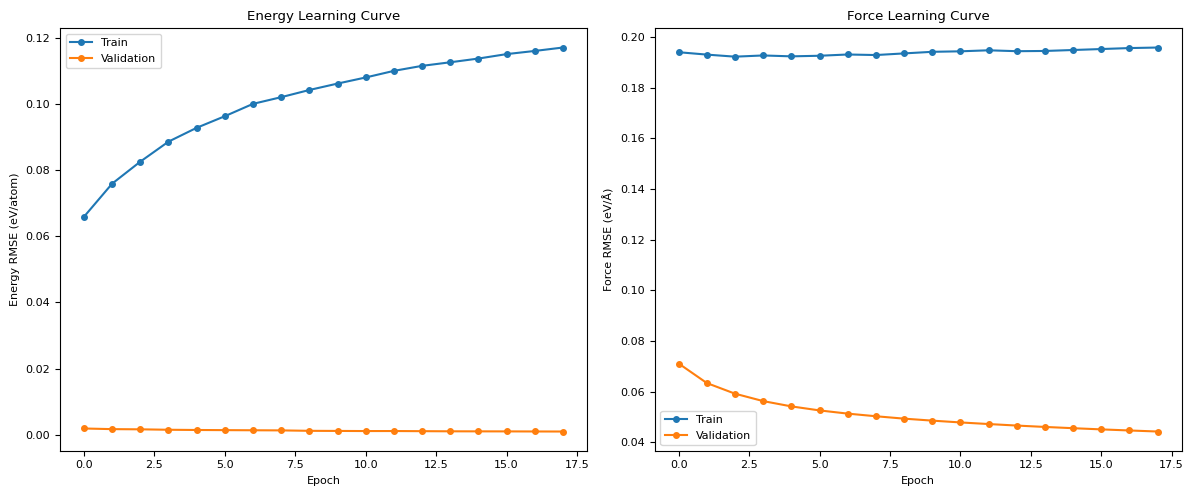

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import json
from google.colab import drive

# 1. Mount your Google Drive
drive.mount('/content/drive')

# 2. Path to your file
results_file = "/content/drive/MyDrive/MDProject/results/model_3000_pts_run-1_train.txt"

# 3. Read the JSON Lines file
data = []
with open(results_file, 'r') as f:
    for line in f:
        if line.strip():
            try:
                data.append(json.loads(line.strip()))
            except json.JSONDecodeError:
                pass

# Convert to DataFrame
df = pd.DataFrame(data)

# 4. Clean and split the data
# Drop the initial setup rows where 'epoch' is null
df = df.dropna(subset=['epoch']).copy()

# Get all evaluation rows
df_eval = df[df['mode'] == 'eval'].copy()

# Separate the two alternating evaluation metrics per epoch
# keep='first' grabs the first evaluation (Train)
# keep='last' grabs the second evaluation (Validation)
df_train_eval = df_eval.drop_duplicates(subset=['epoch'], keep='first')
df_valid_eval = df_eval.drop_duplicates(subset=['epoch'], keep='last')

# 5. Setup the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Energy RMSE
ax1.plot(df_train_eval['epoch'], df_train_eval['rmse_e_per_atom'], label='Train', marker='o', markersize=4)
ax1.plot(df_valid_eval['epoch'], df_valid_eval['rmse_e_per_atom'], label='Validation', marker='o', markersize=4)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Energy RMSE (eV/atom)')
ax1.set_title('Energy Learning Curve')
ax1.legend()

# Plot Force RMSE
ax2.plot(df_train_eval['epoch'], df_train_eval['rmse_f'], label='Train', marker='o', markersize=4)
ax2.plot(df_valid_eval['epoch'], df_valid_eval['rmse_f'], label='Validation', marker='o', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Force RMSE (eV/Å)')
ax2.set_title('Force Learning Curve')
ax2.legend()

plt.tight_layout()
plt.show()

Despite the fine tuning of the hyperparameters performed as instructed in the MACE documentation we see some problematics in the learning, with somewhat successful results in the force learning curve and an anomalous behavior in the energy learing curve.

Given this results we try from now on to find possible improvements to the learning pipeline.

One of the goals of MACE is creating a simulation that, without the computational complexity of the DFT simulation, returns physically acceptable results that can, in a setting that requires less accuracy, give prediction of the characteristics of the species we are analyzing. For this purpose, given the training performed with MACE we simulate the trajectory of particles, hoping to obtain physical indicators that are close to real data or to way more accurate (but computational very expensive) simulations

### ASE simulation of the trajectory

Cell to turn the MACE checkpoint into a MACE model for the simulation

In [ ]:
import sys
from mace.cli.run_train import main as mace_train_main

custom_args = [
    "mace_run_training",
    "--name=model_3000_pts_run-1", # FIXED: Reverted to base name. MACE will find the epoch-17 file automatically.

    "--train_file=/content/drive/MyDrive/MDProject/new_data/1.NVT_300/A.1_10K/train.extxyz",
    "--valid_file=/content/drive/MyDrive/MDProject/new_data/1.NVT_300/A.1_10K/valid.extxyz",
    "--checkpoints_dir=/content/drive/MyDrive/MDProject/new_simulation/1.NVT_300/A.1_10K/checkpoints",
    "--results_dir=/content/drive/MyDrive/MDProject/new_simulation/1.NVT_300/A.1_10K/results",

    # FIXED: Reverted back to REF_ to match your ASE extraction script
    "--energy_key=energy",   # Change this to match your file
    "--forces_key=forces",   # Change this to match your file
    "--stress_key=stress",   # Change this to match your file

    "--E0s=foundation",
    "--stress_weight=1.0",
    "--compute_stress=True",
    "--device=cuda",
    "--default_dtype=float32",
    "--r_max=5.0",
    "--num_channels=64",
    "--max_L=0",
    "--seed=1",
    "--foundation_model=small",
    "--multiheads_finetuning=True",
    "--pt_train_file=mp",
    "--atomic_numbers=[1, 6, 7, 50, 53]",
    "--num_samples_pt=1000",
    "--scaling=rms_forces_scaling",
    "--ema",
    "--swa",

    # --- THE FIX ---
    "--restart_latest",       # Automatically finds the epoch-17 checkpoint based on the --name
    "--max_num_epochs=18"     # Forces the script to run exactly 1 step (17 -> 18) and trigger the save
]

sys.argv = custom_args
mace_train_main()

INFO:root:===========VERIFYING SETTINGS===========


2026-09-16 16:10:28.202 INFO: ===========VERIFYING SETTINGS===========
2026-09-16 16:10:28.202 INFO: ===========VERIFYING SETTINGS===========
2026-09-16 16:10:28.202 INFO: ===========VERIFYING SETTINGS===========
2026-09-16 16:10:28.202 INFO: ===========VERIFYING SETTINGS===========
2026-09-16 16:10:28.202 INFO: ===========VERIFYING SETTINGS===========
2026-09-16 16:10:28.202 INFO: ===========VERIFYING SETTINGS===========
2026-09-16 16:10:28.202 INFO: ===========VERIFYING SETTINGS===========
2026-09-16 16:10:28.202 INFO: ===========VERIFYING SETTINGS===========
2026-09-16 16:10:28.202 INFO: ===========VERIFYING SETTINGS===========


INFO:root:MACE version: 0.3.16


2026-09-16 16:10:28.213 INFO: MACE version: 0.3.16
2026-09-16 16:10:28.213 INFO: MACE version: 0.3.16
2026-09-16 16:10:28.213 INFO: MACE version: 0.3.16
2026-09-16 16:10:28.213 INFO: MACE version: 0.3.16
2026-09-16 16:10:28.213 INFO: MACE version: 0.3.16
2026-09-16 16:10:28.213 INFO: MACE version: 0.3.16
2026-09-16 16:10:28.213 INFO: MACE version: 0.3.16
2026-09-16 16:10:28.213 INFO: MACE version: 0.3.16
2026-09-16 16:10:28.213 INFO: MACE version: 0.3.16


DEBUG:root:Configuration: Namespace(config=None, name='model_3000_pts_run-1', seed=1, work_dir='.', log_dir='./logs', model_dir='.', checkpoints_dir='/content/drive/MyDrive/MDProject/new_simulation/1.NVT_300/A.1_10K/checkpoints', results_dir='/content/drive/MyDrive/MDProject/new_simulation/1.NVT_300/A.1_10K/results', downloads_dir='./downloads', device='cuda', default_dtype='float32', distributed=False, launcher='slurm', log_level='INFO', plot=True, plot_frequency=0, plot_interaction_e=False, error_table='PerAtomRMSE', model='MACE', r_max=5.0, radial_type='bessel', num_radial_basis=8, num_cutoff_basis=5, pair_repulsion=False, distance_transform='None', apply_cutoff=True, use_last_readout_only=False, use_embedding_readout=False, interaction='RealAgnosticResidualInteractionBlock', interaction_first='RealAgnosticResidualInteractionBlock', max_ell=3, correlation=3, use_reduced_cg=False, use_so3=False, use_agnostic_product=False, num_interactions=2, MLP_irreps='16x0e', radial_MLP='[64, 64, 

...

2026-09-16 16:26:03.906 INFO: Skipping evaluation of valid_pt_head (in skip_heads list)
2026-09-16 16:26:03.906 INFO: Skipping evaluation of valid_pt_head (in skip_heads list)
2026-09-16 16:26:03.906 INFO: Skipping evaluation of valid_pt_head (in skip_heads list)
2026-09-16 16:26:03.906 INFO: Skipping evaluation of valid_pt_head (in skip_heads list)
2026-09-16 16:26:03.906 INFO: Skipping evaluation of valid_pt_head (in skip_heads list)
2026-09-16 16:26:03.906 INFO: Skipping evaluation of valid_pt_head (in skip_heads list)
2026-09-16 16:26:03.906 INFO: Skipping evaluation of valid_pt_head (in skip_heads list)
2026-09-16 16:26:03.906 INFO: Skipping evaluation of valid_pt_head (in skip_heads list)
2026-09-16 16:26:03.906 INFO: Skipping evaluation of valid_pt_head (in skip_heads list)


INFO:root:Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+---------------------------------------+
|  config_type  | RMSE E / meV / atom | RMSE F / meV / A | relative F RMSE % | RMSE Stress (Virials) / meV / A (A^3) |
+---------------+---------------------+------------------+-------------------+---------------------------------------+
| train_Default |            2.8      |         68.8     |         20.31     |                     3.1               |
| valid_Default |            3.2      |         70.0     |         20.57     |                     3.0               |
+---------------+---------------------+------------------+-------------------+---------------------------------------+


2026-09-16 16:26:03.923 INFO: Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+---------------------------------------+
|  config_type  | RMSE E / meV / atom | RMSE F / meV / A | relative F RMSE % | RMSE Stress (Virials) / meV / A (A^3) |
+---------------+---------------------+------------------+-------------------+---------------------------------------+
| train_Default |            2.8      |         68.8     |         20.31     |                     3.1               |
| valid_Default |            3.2      |         70.0     |         20.57     |                     3.0               |
+---------------+---------------------+------------------+-------------------+---------------------------------------+
2026-09-16 16:26:03.923 INFO: Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+---------------------------------------+
|  config_type  | RMSE E / meV / atom | RMS

DEBUG:root:Running inference on train_Default dataset
DEBUG:root:Running inference on train_pt_head dataset
DEBUG:root:Running inference on valid_pt_head dataset
DEBUG:root:Running inference on valid_Default dataset
INFO:root:Done


2026-09-16 16:26:32.096 INFO: Done
2026-09-16 16:26:32.096 INFO: Done
2026-09-16 16:26:32.096 INFO: Done
2026-09-16 16:26:32.096 INFO: Done
2026-09-16 16:26:32.096 INFO: Done
2026-09-16 16:26:32.096 INFO: Done
2026-09-16 16:26:32.096 INFO: Done
2026-09-16 16:26:32.096 INFO: Done
2026-09-16 16:26:32.096 INFO: Done


In [ ]:
!head -n 2 /content/drive/MyDrive/MDProject/new_data/1.NVT_300/A.1_10K/train.extxyz


100
Lattice="8.742892963 0.0 -0.031376383 0.0 8.422714245 0.0 -3.957950916 0.0 20.036876932" Properties=species:S:1:pos:R:3:forces:R:3 stress="-0.003830570188282703 0.0008885786882154959 0.000501817333721014 0.0008885786882154959 0.005017268318386887 0.0002194327363386777 0.000501817333721014 0.0002194327363386777 0.00012624076358011478" free_energy=-479.500394 energy=-479.500394 pbc="T T T"


In [ ]:
import os
import time
from ase.io import read, write
from ase import units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from mace.calculators import MACECalculator
from google.colab import drive

# 1. Mount your Google Drive
drive.mount('/content/drive')

# 2. Define your paths
model_path = "/content/drive/MyDrive/MDProject/new_simulation/1.NVT_300/A.1_10K/checkpoints/model_3000_pts_run-1_run-1_stagetwo.model"
init_structure_path = "/content/drive/MyDrive/MDProject/new_data/1.NVT_300/A.1_10K/test.extxyz"
output_traj_path = "/content/drive/MyDrive/MDProject/results/md_trajectory_run-1_epoch-17.extxyz"

# 3. Load the initial structure
print("Loading initial structure...")
atoms = read(init_structure_path, index=0)

# 4. Initialize the trained MACE Calculator using the compiled model
print(f"Loading MACE calculator from: {model_path}...")
calculator = MACECalculator(
    model_paths=[model_path], # Using model_paths (plural list) to satisfy the warning
    device='cuda',
    default_dtype='float32'
)
atoms.calc = calculator

# 5. Set up the Molecular Dynamics Simulation (NVT Ensemble at 300K)
temperature_K = 300
timestep_fs = 1.0
friction_coeff = 0.001

print(f"Initializing velocities at {temperature_K} K...")
MaxwellBoltzmannDistribution(atoms, temperature_K=temperature_K)

dyn = Langevin(
    atoms,
    timestep_fs * units.fs,
    temperature_K=temperature_K,
    friction=friction_coeff
)

# 6. Define an output function to save frames during the run
def write_frame():
    epot = atoms.get_potential_energy()
    ekin = atoms.get_kinetic_energy()
    temp = ekin / (1.5 * units.kB * len(atoms))

    write(output_traj_path, atoms, append=True)

    print(f"Step: {dyn.get_number_of_steps():>4} | Temp: {temp:>6.1f} K | Epot: {epot:+.3f} eV | Total: {epot+ekin:+.3f} eV")

if os.path.exists(output_traj_path):
    os.remove(output_traj_path)

dyn.attach(write_frame, interval=10)

# 7. Run the simulation
num_steps = 1000
print(f"\nStarting MD simulation for {num_steps} steps...")
start_time = time.time()

dyn.run(num_steps)

print(f"\nMD simulation finished in {time.time() - start_time:.2f} seconds!")
print(f"Trajectory saved to: {output_traj_path}")

/usr/local/lib/python3.13/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
INFO:root:CUDA version: 12.8, CUDA device: 0


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading initial structure...
Loading MACE calculator from: /content/drive/MyDrive/MDProject/new_simulation/1.NVT_300/A.1_10K/checkpoints/model_3000_pts_run-1_run-1_stagetwo.model...
2026-09-16 16:29:38.048 INFO: CUDA version: 12.8, CUDA device: 0
2026-09-16 16:29:38.048 INFO: CUDA version: 12.8, CUDA device: 0
2026-09-16 16:29:38.048 INFO: CUDA version: 12.8, CUDA device: 0
2026-09-16 16:29:38.048 INFO: CUDA version: 12.8, CUDA device: 0
2026-09-16 16:29:38.048 INFO: CUDA version: 12.8, CUDA device: 0
2026-09-16 16:29:38.048 INFO: CUDA version: 12.8, CUDA device: 0
2026-09-16 16:29:38.048 INFO: CUDA version: 12.8, CUDA device: 0
2026-09-16 16:29:38.048 INFO: CUDA version: 12.8, CUDA device: 0
2026-09-16 16:29:38.048 INFO: CUDA version: 12.8, CUDA device: 0


INFO:root:Using head Default out of  ['pt_head', 'Default']


2026-09-16 16:29:38.058 INFO: Using head Default out of  ['pt_head', 'Default']
2026-09-16 16:29:38.058 INFO: Using head Default out of  ['pt_head', 'Default']
2026-09-16 16:29:38.058 INFO: Using head Default out of  ['pt_head', 'Default']
2026-09-16 16:29:38.058 INFO: Using head Default out of  ['pt_head', 'Default']
2026-09-16 16:29:38.058 INFO: Using head Default out of  ['pt_head', 'Default']
2026-09-16 16:29:38.058 INFO: Using head Default out of  ['pt_head', 'Default']
2026-09-16 16:29:38.058 INFO: Using head Default out of  ['pt_head', 'Default']
2026-09-16 16:29:38.058 INFO: Using head Default out of  ['pt_head', 'Default']
2026-09-16 16:29:38.058 INFO: Using head Default out of  ['pt_head', 'Default']


/tmp/ipykernel_638/2998285315.py:37: DeprecationWarning: Use thermalize_momenta
  MaxwellBoltzmannDistribution(atoms, temperature_K=temperature_K)
/usr/local/lib/python3.13/dist-packages/ase/md/langevin.py:102: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


Initializing velocities at 300 K...

Starting MD simulation for 1000 steps...
Step:    0 | Temp:  288.0 K | Epot: -479.355 eV | Total: -475.632 eV
Step:   10 | Temp:  244.9 K | Epot: -478.745 eV | Total: -475.579 eV
Step:   20 | Temp:  224.0 K | Epot: -478.462 eV | Total: -475.567 eV
Step:   30 | Temp:  253.5 K | Epot: -478.852 eV | Total: -475.575 eV
Step:   40 | Temp:  283.6 K | Epot: -479.249 eV | Total: -475.584 eV
Step:   50 | Temp:  303.1 K | Epot: -479.488 eV | Total: -475.570 eV
Step:   60 | Temp:  302.8 K | Epot: -479.501 eV | Total: -475.588 eV
Step:   70 | Temp:  301.3 K | Epot: -479.504 eV | Total: -475.610 eV
Step:   80 | Temp:  305.6 K | Epot: -479.603 eV | Total: -475.652 eV
Step:   90 | Temp:  308.4 K | Epot: -479.648 eV | Total: -475.661 eV
Step:  100 | Temp:  308.5 K | Epot: -479.630 eV | Total: -475.642 eV
Step:  110 | Temp:  315.7 K | Epot: -479.724 eV | Total: -475.644 eV
Step:  120 | Temp:  305.8 K | Epot: -479.613 eV | Total: -475.661 eV
Step:  130 | Temp:  320.6

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Comparison between key physical indicators in the between the MACE simulation and DFT simulation in same enviromental conditions

In [ ]:
import os
import numpy as np
from ase.io import read, write

outcar_file = "/content/drive/MyDrive/MDProject/OUTCAR"
data_dir = "/content/drive/MyDrive/MDProject/new_data/1.NVT_300/A.1_10K"
os.makedirs(data_dir, exist_ok=True)

print("1. Reading atomic positions with ASE...")
# ASE successfully reads the positions, we just need to inject the missing data
all_frames = read(outcar_file, index=":", format="vasp-out")
n_atoms = len(all_frames[0])
print(f"Loaded {len(all_frames)} coordinate frames.")

print("2. Manually extracting Energies and Forces from OUTCAR...")
energies = []
forces = []

with open(outcar_file, 'r') as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    # Extract Energy
    if "free  energy   TOTEN" in line:
        energies.append(float(line.split()[-2]))

    # Extract Forces
    if "POSITION                                       TOTAL-FORCE" in line:
        frame_forces = []
        # Skip the dashes (i+1) and read the next n_atoms lines
        for j in range(n_atoms):
            parts = lines[i + 2 + j].split()
            # Forces are in columns 3, 4, 5 (0-indexed)
            frame_forces.append([float(parts[3]), float(parts[4]), float(parts[5])])
        forces.append(frame_forces)

print(f"Found {len(energies)} energies and {len(forces)} force blocks.")

# Truncate to the minimum length in case the VASP run was cut off mid-step
min_len = min(len(all_frames), len(energies), len(forces))
all_frames = all_frames[:min_len]
energies = energies[:min_len]
forces = forces[:min_len]

print("3. Injecting correct data into ASE frames...")
for idx, frame in enumerate(all_frames):
    # Notice we are naming them REF_energy and REF_forces directly!
    frame.info['REF_energy'] = energies[idx]
    frame.arrays['REF_forces'] = np.array(forces[idx])

print("4. Subsampling and Splitting...")
# Start at 6840 and take every 5th frame
subsampled_frames = all_frames[6840::5]
print(f"Subsampled down to {len(subsampled_frames)} frames.")

# Shuffle
np.random.seed(42)
np.random.shuffle(subsampled_frames)

# Split 80/10/10
n_total = len(subsampled_frames)
n_train = int(0.8 * n_total)
n_valid = int(0.1 * n_total)

train_frames = subsampled_frames[:n_train]
valid_frames = subsampled_frames[n_train : n_train + n_valid]
test_frames = subsampled_frames[n_train + n_valid:]

# Save
write(f"{data_dir}/train.extxyz", train_frames, format="extxyz")
write(f"{data_dir}/valid.extxyz", valid_frames, format="extxyz")
write(f"{data_dir}/test.extxyz", test_frames, format="extxyz")

print(f"SUCCESS! Saved {len(train_frames)} train, {len(valid_frames)} valid, and {len(test_frames)} test frames.")

1. Reading atomic positions with ASE...
Loaded 10000 coordinate frames.
2. Manually extracting Energies and Forces from OUTCAR...
Found 10000 energies and 10000 force blocks.
3. Injecting correct data into ASE frames...
4. Subsampling and Splitting...
Subsampled down to 632 frames.
SUCCESS! Saved 505 train, 63 valid, and 64 test frames.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading test frames and MACE model...


/usr/local/lib/python3.13/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
INFO:root:CUDA version: 12.8, CUDA device: 0


2026-09-16 16:52:02.800 INFO: CUDA version: 12.8, CUDA device: 0
2026-09-16 16:52:02.800 INFO: CUDA version: 12.8, CUDA device: 0
2026-09-16 16:52:02.800 INFO: CUDA version: 12.8, CUDA device: 0
2026-09-16 16:52:02.800 INFO: CUDA version: 12.8, CUDA device: 0
2026-09-16 16:52:02.800 INFO: CUDA version: 12.8, CUDA device: 0
2026-09-16 16:52:02.800 INFO: CUDA version: 12.8, CUDA device: 0
2026-09-16 16:52:02.800 INFO: CUDA version: 12.8, CUDA device: 0
2026-09-16 16:52:02.800 INFO: CUDA version: 12.8, CUDA device: 0
2026-09-16 16:52:02.800 INFO: CUDA version: 12.8, CUDA device: 0


INFO:root:Using head Default out of  ['pt_head', 'Default']


2026-09-16 16:52:02.813 INFO: Using head Default out of  ['pt_head', 'Default']
2026-09-16 16:52:02.813 INFO: Using head Default out of  ['pt_head', 'Default']
2026-09-16 16:52:02.813 INFO: Using head Default out of  ['pt_head', 'Default']
2026-09-16 16:52:02.813 INFO: Using head Default out of  ['pt_head', 'Default']
2026-09-16 16:52:02.813 INFO: Using head Default out of  ['pt_head', 'Default']
2026-09-16 16:52:02.813 INFO: Using head Default out of  ['pt_head', 'Default']
2026-09-16 16:52:02.813 INFO: Using head Default out of  ['pt_head', 'Default']
2026-09-16 16:52:02.813 INFO: Using head Default out of  ['pt_head', 'Default']
2026-09-16 16:52:02.813 INFO: Using head Default out of  ['pt_head', 'Default']


2026-09-16 16:52:02.821 WARNING: Default dtype float64 does not match model dtype float32, converting models to float64.
2026-09-16 16:52:02.821 WARNING: Default dtype float64 does not match model dtype float32, converting models to float64.
2026-09-16 16:52:02.821 WARNING: Default dtype float64 does not match model dtype float32, converting models to float64.
2026-09-16 16:52:02.821 WARNING: Default dtype float64 does not match model dtype float32, converting models to float64.
2026-09-16 16:52:02.821 WARNING: Default dtype float64 does not match model dtype float32, converting models to float64.
2026-09-16 16:52:02.821 WARNING: Default dtype float64 does not match model dtype float32, converting models to float64.
2026-09-16 16:52:02.821 WARNING: Default dtype float64 does not match model dtype float32, converting models to float64.
2026-09-16 16:52:02.821 WARNING: Default dtype float64 does not match model dtype float32, converting models to float64.
2026-09-16 16:52:02.821 WARNING:

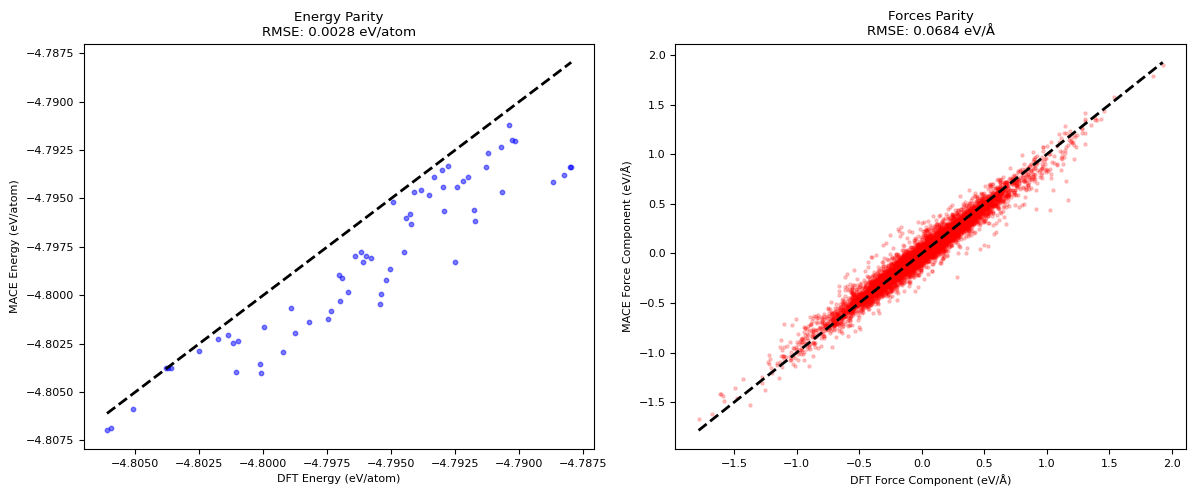

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
from mace.calculators import MACECalculator
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Paths
model_path = "/content/drive/MyDrive/MDProject/new_simulation/1.NVT_300/A.1_10K/checkpoints/model_3000_pts_run-1_run-1_stagetwo.model"
test_file_path = "/content/drive/MyDrive/MDProject/new_data/1.NVT_300/A.1_10K/test.extxyz"

# 3. Load Test Data and Model
print("Loading test frames and MACE model...")
test_frames = read(test_file_path, index=":")
calculator = MACECalculator(model_paths=[model_path], device='cuda', default_dtype='float64')

# --- AUTO-DETECT KEYS ---
sample_frame = test_frames[0]
info_keys = list(sample_frame.info.keys())
array_keys = list(sample_frame.arrays.keys())

# Detect Energy Key
dft_e_key = None
for k in ['REF_energy', 'energy', 'free_energy', 'dft_energy']:
    if k in info_keys:
        dft_e_key = k
        break

# Detect Forces Key
dft_f_key = None
for k in ['REF_forces', 'forces', 'dft_forces']:
    if k in array_keys:
        dft_f_key = k
        break

if not dft_e_key or not dft_f_key:
    print(f"AVAILABLE INFO (Energy) KEYS: {info_keys}")
    print(f"AVAILABLE ARRAY (Forces) KEYS: {array_keys}")
    raise ValueError("Could not automatically find the keys! Check the printed lists above.")

print(f"--> Auto-detected Energy Key: '{dft_e_key}'")
print(f"--> Auto-detected Forces Key: '{dft_f_key}'")
# ------------------------

# Lists to store the data
dft_energies, mace_energies = [], []
dft_forces, mace_forces = [], []

print(f"Evaluating {len(test_frames)} frames. This may take a moment...")

# 4. Evaluate each frame
for atoms in test_frames:
    # --- Energy ---
    # Using the auto-detected key
    e_dft = atoms.info[dft_e_key]

    # Calculate MACE energy
    atoms.calc = calculator
    e_mace = atoms.get_potential_energy()

    # Divide by number of atoms for a fair per-atom comparison
    n_atoms = len(atoms)
    dft_energies.append(e_dft / n_atoms)
    mace_energies.append(e_mace / n_atoms)

    # --- Forces ---
    # Using the auto-detected key
    f_dft = atoms.arrays[dft_f_key].flatten()
    f_mace = atoms.get_forces().flatten()

    dft_forces.extend(f_dft)
    mace_forces.extend(f_mace)

# Convert to numpy arrays for math
dft_energies = np.array(dft_energies)
mace_energies = np.array(mace_energies)
dft_forces = np.array(dft_forces)
mace_forces = np.array(mace_forces)

# Calculate RMSE
rmse_e = np.sqrt(np.mean((mace_energies - dft_energies)**2))
rmse_f = np.sqrt(np.mean((mace_forces - dft_forces)**2))

# 5. Plotting the Parity Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Energy Parity Plot
ax1.scatter(dft_energies, mace_energies, alpha=0.5, s=10, color='blue')
# Draw the perfect agreement diagonal line y=x
min_e, max_e = min(dft_energies), max(dft_energies)
ax1.plot([min_e, max_e], [min_e, max_e], 'k--', lw=2)

ax1.set_xlabel('DFT Energy (eV/atom)')
ax1.set_ylabel('MACE Energy (eV/atom)')
ax1.set_title(f'Energy Parity\nRMSE: {rmse_e:.4f} eV/atom')

# Force Parity Plot
# Sampling a subset of forces if there are too many (e.g., millions) to avoid crashing matplotlib
plot_subset = np.random.choice(len(dft_forces), min(10000, len(dft_forces)), replace=False)
ax2.scatter(dft_forces[plot_subset], mace_forces[plot_subset], alpha=0.2, s=5, color='red')
# Draw diagonal line
min_f, max_f = min(dft_forces), max(dft_forces)
ax2.plot([min_f, max_f], [min_f, max_f], 'k--', lw=2)

ax2.set_xlabel('DFT Force Component (eV/Å)')
ax2.set_ylabel('MACE Force Component (eV/Å)')
ax2.set_title(f'Forces Parity\nRMSE: {rmse_f:.4f} eV/Å')

plt.tight_layout()
plt.show()

RDF analysis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Define paths to your two trajectories
dft_traj_path = "/content/drive/MyDrive/MDProject/new_data/1.NVT_300/A.1_10K/test.extxyz"
mace_traj_path = "/content/drive/MyDrive/MDProject/results/md_trajectory_run-1.extxyz"

# 2. Load the trajectories
print("Loading trajectories...")
dft_images = read(dft_traj_path, index=":")
mace_images = read(mace_traj_path, index=":")

print(f"Loaded {len(dft_images)} DFT frames and {len(mace_images)} MACE frames.")

# 3. Define your RDF parameters
rmax = 3.9  # Maximum distance (constrained by cell dimension)
nbins = 1000

# 4. Helper function using your exact RDF logic
def compute_time_averaged_rdf(images, rmax, nbins):
    all_rdfs = []
    distances = None

    for atoms in images:
        # Assumes get_rdf is already defined in your notebook
        rdf_values, dists = get_rdf(atoms, rmax=rmax, nbins=nbins)
        all_rdfs.append(rdf_values)
        if distances is None:
            distances = dists

    avg_rdf = np.mean(all_rdfs, axis=0)
    return distances, avg_rdf

# 5. Compute both time-averaged RDFs
print("Computing DFT RDF...")
dft_distances, dft_avg_rdf = compute_time_averaged_rdf(dft_images, rmax=rmax, nbins=nbins)

print("Computing MACE RDF...")
mace_distances, mace_avg_rdf = compute_time_averaged_rdf(mace_images, rmax=rmax, nbins=nbins)

# 6. Plot the comparison
plt.figure(figsize=(14, 6))

# Plot DFT Reference
plt.plot(dft_distances, dft_avg_rdf, color='black', lw=2, label='VASP (DFT) Reference')

# Plot MACE MD
plt.plot(mace_distances, mace_avg_rdf, color='red', lw=2, linestyle='--', label='MACE MD Simulation')

plt.xlabel('Distance r (Å)', fontsize=12)
plt.ylabel('g(r)', fontsize=12)
plt.title('Radial Distribution Function Comparison: MACE vs. DFT', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.xlim(0, rmax)

plt.tight_layout()
plt.show()

Mounted at /content/drive
Loading trajectories...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/MDProject/results/md_trajectory_run-1.extxyz'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading trajectories...
Loaded 64 DFT frames and 101 MACE frames.
Computing DFT RDF...
Computing MACE RDF...


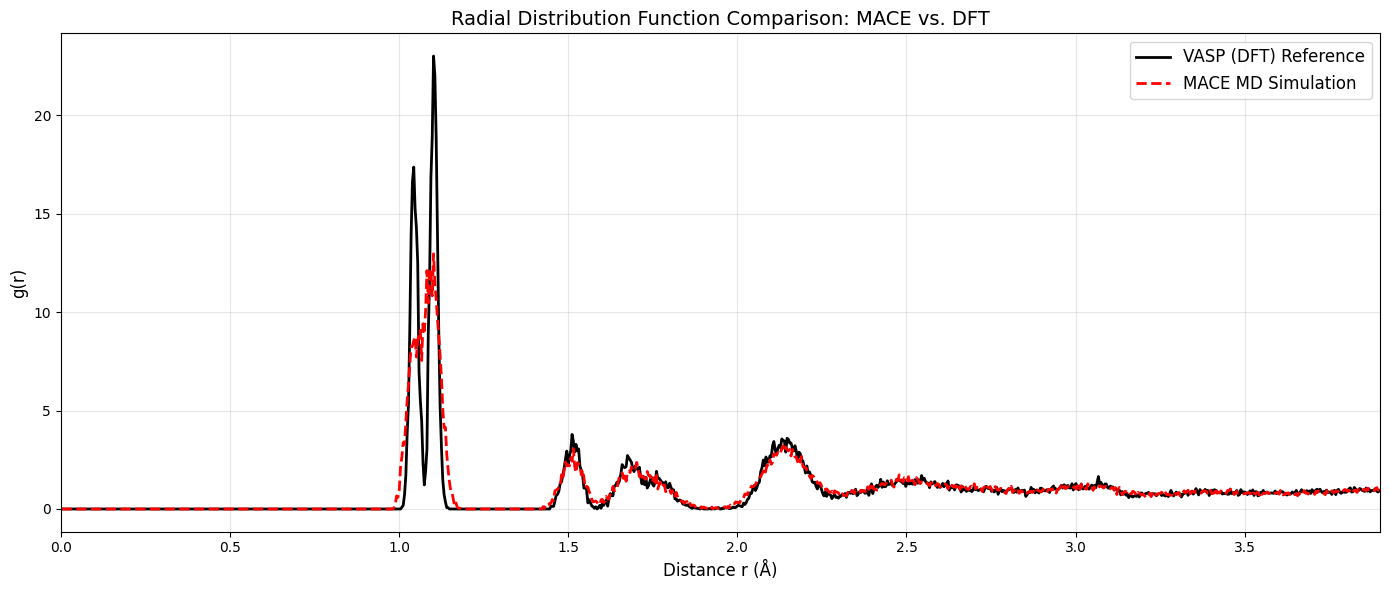

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
from google.colab import drive
from ase.geometry.rdf import get_rdf
# 1. Mount Drive (just in case)
drive.mount('/content/drive')

# 2. Define exact paths to your two trajectories
dft_traj_path = "/content/drive/MyDrive/MDProject/new_data/1.NVT_300/A.1_10K/test.extxyz"
mace_traj_path = "/content/drive/MyDrive/MDProject/results/md_trajectory_run-1_epoch-17.extxyz"

# 3. Load the trajectories
print("Loading trajectories...")
dft_images = read(dft_traj_path, index=":")
mace_images = read(mace_traj_path, index=":")

print(f"Loaded {len(dft_images)} DFT frames and {len(mace_images)} MACE frames.")

# 4. Define your RDF parameters
rmax = 3.9  # Maximum distance (constrained by cell dimension)
nbins = 1000

# 5. Helper function using your exact RDF logic
def compute_time_averaged_rdf(images, rmax, nbins):
    all_rdfs = []
    distances = None

    for atoms in images:
        # Assumes your custom get_rdf function is already defined in the notebook!
        rdf_values, dists = get_rdf(atoms, rmax=rmax, nbins=nbins)
        all_rdfs.append(rdf_values)
        if distances is None:
            distances = dists

    avg_rdf = np.mean(all_rdfs, axis=0)
    return distances, avg_rdf

# 6. Compute both time-averaged RDFs
print("Computing DFT RDF...")
dft_distances, dft_avg_rdf = compute_time_averaged_rdf(dft_images, rmax=rmax, nbins=nbins)

print("Computing MACE RDF...")
mace_distances, mace_avg_rdf = compute_time_averaged_rdf(mace_images, rmax=rmax, nbins=nbins)

# 7. Plot the comparison
plt.figure(figsize=(14, 6))

# Plot DFT Reference
plt.plot(dft_distances, dft_avg_rdf, color='black', lw=2, label='VASP (DFT) Reference')

# Plot MACE MD
plt.plot(mace_distances, mace_avg_rdf, color='red', lw=2, linestyle='--', label='MACE MD Simulation')

plt.xlabel('Distance r (Å)', fontsize=12)
plt.ylabel('g(r)', fontsize=12)
plt.title('Radial Distribution Function Comparison: MACE vs. DFT', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.xlim(0, rmax)

plt.tight_layout()
plt.show()

In [ ]:
# RMSE_F (forces): Default head - for MD-quality models, sub-50 meV/Å is commonly considered good, sub-20-30 meV/Å is very good.
# RMSE_E_per_atom (energy): Default head's sub-few-meV/atom is typical for usable models.

In [ ]:
# TO DO: a) fix warnings (expecially "energy" and "forces" keys),
# b) test??

# Autocorrelation issue

Given the way MACE learns the configuration, feeding the network with contiguous structure that do not differ in a significant way and are highly correlated could reduce the effeciency of the learning. To fix this issue we try to reduce this correlation bias by subsampling the structures in the trajectory and shuffling the structures.

In [ ]:
import os
import numpy as np
from ase.io import read, write
from google.colab import drive

# Mount Google Drive to access the MDProject folder
drive.mount('/content/drive')

# Define file paths
# Point directly to the OUTCAR file inside your Google Drive
outcar_file = "/content/drive/MyDrive/MDProject/OUTCAR"

# FIXED: Changed from local "./new_data" to Google Drive path
data_dir = "/content/drive/MyDrive/MDProject/new_data/1.NVT_300/A.1_10K"
os.makedirs(data_dir, exist_ok=True)

train_file = f"{data_dir}/train.extxyz"
valid_file = f"{data_dir}/valid.extxyz"
test_file = f"{data_dir}/test.extxyz"

# Start at frame 6840 and take every 5th frame
print("Reading and subsampling OUTCAR...")
frames = read(outcar_file, index="6840::5", format="vasp-out")
print(f"Extracted {len(frames)} distinct frames.")

# Randomize the order to prevent data leakage across splits
np.random.seed(42) # For reproducibility
np.random.shuffle(frames)

# FIX ASE KEYS: Rename keys to avoid ASE 3.23+ conflicts with MACE
print("Renaming ASE internal keys...")
for frame in frames:
    if 'energy' in frame.info:
        frame.info['REF_energy'] = frame.info.pop('energy')
    if 'stress' in frame.info:
        frame.info['REF_stress'] = frame.info.pop('stress')
    if 'forces' in frame.arrays:
        frame.arrays['REF_forces'] = frame.arrays.pop('forces')

# SPLIT: 80% Train, 10% Valid, 10% Test
n_total = len(frames)
n_train = int(0.8 * n_total)
n_valid = int(0.1 * n_total)

train_frames = frames[:n_train]
valid_frames = frames[n_train : n_train + n_valid]
test_frames = frames[n_train + n_valid:]

# SAVE
write(train_file, train_frames, format="extxyz")
write(valid_file, valid_frames, format="extxyz")
write(test_file, test_frames, format="extxyz")

print(f"Saved {len(train_frames)} train, {len(valid_frames)} valid, and {len(test_frames)} test frames.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading and subsampling OUTCAR...


KeyboardInterrupt: 

In [ ]:
import sys
from mace.cli.run_train import main as mace_train_main

# 1. Define your Google Drive paths
my_train_file = "/content/drive/MyDrive/MDProject/new_data/1.NVT_300/A.1_10K/train.extxyz"
my_valid_file = "/content/drive/MyDrive/MDProject/new_data/1.NVT_300/A.1_10K/valid.extxyz"
my_sim_checkpoints_dir = "/content/drive/MyDrive/MDProject/new_simulation/1.NVT_300/A.1_10K/checkpoints"
my_sim_results_dir = "/content/drive/MyDrive/MDProject/new_simulation/1.NVT_300/A.1_10K/results"
my_atomic_numbers = "[1, 6, 7, 50, 53]"

# 2. Your full configuration list
custom_args = [
    "mace_run_training",
    "--name=model_3000_pts",

    # FIXED: These now point to the Drive variables above
    f"--train_file={my_train_file}",
    f"--valid_file={my_valid_file}",
    f"--checkpoints_dir={my_sim_checkpoints_dir}",
    f"--results_dir={my_sim_results_dir}",

    # FIXED: Data keys separated properly
    "--energy_key=energy",
    "--forces_key=forces",
    "--stress_key=stress",

    "--E0s=foundation",
    "--stress_weight=1.0",
    "--compute_stress=True",

    "--max_num_epochs=50",
    "--patience=10",
    "--batch_size=5",
    "--valid_batch_size=5",
    "--device=cuda",
    "--default_dtype=float32",

    "--r_max=5.0",

    "--keep_checkpoints",

    "--num_channels=64",
    "--max_L=0",
    "--seed=1",

    # pre-trained ("foundation") model
    "--foundation_model=small",
    "--multiheads_finetuning=True",
    "--pt_train_file=mp",

    f"--atomic_numbers={my_atomic_numbers}",
    "--num_samples_pt=1000",
    "--lr=0.0001",

    "--energy_weight=1.0",
    "--forces_weight=100.0",

    # OPTIMIZER
    "--optimizer=adamw",
    "--amsgrad",
    "--weight_decay=5e-7",

    # EMA/SWA
    "--ema",
    "--ema_decay=0.99",

    "--swa",
    "--start_swa=30",

    "--swa_forces_weight=100.0",
    "--swa_stress_weight=1.0",
    "--swa_energy_weight=1.0",

    # SCALING
    "--scaling=rms_forces_scaling"
]

# 3. Run the training
sys.argv = custom_args
mace_train_main()

INFO:root:===========VERIFYING SETTINGS===========


2026-09-17 10:36:09.758 INFO: ===========VERIFYING SETTINGS===========


INFO:root:Stage Two is activated as start_stage_two was defined


2026-09-17 10:36:09.759 INFO: Stage Two is activated as start_stage_two was defined


INFO:root:MACE version: 0.3.16


...

2026-09-17 10:36:09.932 INFO: CUDA version: 12.8, CUDA device: 0


DEBUG:git.cmd:Popen(['git', 'version'], cwd=/content, stdin=None, shell=False, universal_newlines=False)
DEBUG:git.cmd:Popen(['git', 'version'], cwd=/content, stdin=None, shell=False, universal_newlines=False)
DEBUG:git.util:sys.platform='linux', git_executable='git'
DEBUG:root:Error accessing Git repository: /content
INFO:root:Using foundation model mace small as initial checkpoint.


2026-09-17 10:36:10.023 INFO: Using foundation model mace small as initial checkpoint.
Downloading: 100.0% (31.1 MB / 31.1 MB)
Cached MACE model to /root/.cache/mace/20231210mace128L0_energy_epoch249model
Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/usr/local/lib/python3.13/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


KeyboardInterrupt: 

As done before we simulate from the MACE training a trajectory, in order to compare the physical quantities we care about with the DFT simulation.

There is a way to further improve this: using SOAP we can extract the physical descriptors from each frame. Combining this with Farthest Point Sampling (FPS) we can select the most structurally unique frames. Training on 200 perfectly diverse FPS frames will train nearly 10x faster and yield a more robust model than training on 3,000 highly correlated time-sliced frames.

In [ ]:
!pip install dscribe scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 18.1 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
from ase.io import read, write
from dscribe.descriptors import SOAP
from google.colab import drive

# 1. Mount Drive & Setup Paths
drive.mount('/content/drive')
outcar_file = "/content/drive/MyDrive/MDProject/OUTCAR"
data_dir = "/content/drive/MyDrive/MDProject/new_data/1.NVT_300/A.1_10K/Smart_FPS"

os.makedirs(data_dir, exist_ok=True)

# 2. Extract Data from OUTCAR (re-using our bulletproof method)
print("1. Loading OUTCAR positions...")
all_frames = read(outcar_file, index=":", format="vasp-out")
n_atoms = len(all_frames[0])

print("2. Extracting true Energies and Forces...")
energies, forces = [], []
with open(outcar_file, 'r') as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if "free  energy   TOTEN" in line:
        energies.append(float(line.split()[-2]))
    if "POSITION                                       TOTAL-FORCE" in line:
        frame_forces = []
        for j in range(n_atoms):
            parts = lines[i + 2 + j].split()
            frame_forces.append([float(parts[3]), float(parts[4]), float(parts[5])])
        forces.append(frame_forces)

# Truncate to min length and inject data
min_len = min(len(all_frames), len(energies), len(forces))
all_frames = all_frames[:min_len]
for idx, frame in enumerate(all_frames):
    frame.info['REF_energy'] = energies[idx]
    frame.arrays['REF_forces'] = np.array(forces[idx])

# 3. Compute SOAP Fingerprints
print("\n3. Computing SOAP Descriptors ")
species = list(set(all_frames[0].get_chemical_symbols()))

# We use a low-res SOAP config for diversity sampling to save memory/time
soap = SOAP(
    species=species,
    periodic=True,
    r_cut=5.0,     # Cutoff radius
    n_max=4,       # Number of radial basis functions
    l_max=4,       # Number of spherical harmonics basis functions
)

# Compute global fingerprint for each frame (averaging the atomic SOAPs)
global_fingerprints = []
# To save time, we will only evaluate a sub-pool of frames (e.g. every 10th frame)
pool_frames = all_frames[::10]
print(f"Evaluating a pool of {len(pool_frames)} candidate frames...")

for i, frame in enumerate(pool_frames):
    # Get SOAP for all atoms, then average into a single vector for the whole box
    atom_soaps = soap.create(frame)
    frame_soap = np.mean(atom_soaps, axis=0)
    global_fingerprints.append(frame_soap)

    if i % 100 == 0 and i > 0:
        print(f"  Processed {i}/{len(pool_frames)} frames...")

features = np.array(global_fingerprints)

# 4. Farthest Point Sampling (FPS) Algorithm
def fps(features, num_samples):
    print(f"\n4. Running Farthest Point Sampling to select {num_samples} frames...")
    selected_indices = [0] # Start with the first frame

    # Track the shortest distance from each point to the selected set
    min_distances = np.linalg.norm(features - features[0], axis=1)

    for _ in range(1, num_samples):
        # Pick the point that is furthest from the currently selected points
        next_idx = np.argmax(min_distances)
        selected_indices.append(next_idx)

        # Update distances based on the newly added point
        new_distances = np.linalg.norm(features - features[next_idx], axis=1)
        min_distances = np.minimum(min_distances, new_distances)

    return selected_indices

# Let's select exactly 500 highly diverse frames (450 train, 50 valid)
n_target = 500
smart_indices = fps(features, n_target)
smart_frames = [pool_frames[i] for i in smart_indices]

# 5. Split and Save
train_frames = smart_frames[:450]
valid_frames = smart_frames[450:]

write(f"{data_dir}/train_fps.extxyz", train_frames, format="extxyz")
write(f"{data_dir}/valid_fps.extxyz", valid_frames, format="extxyz")

print(f"\nSUCCESS! Smart Selection Complete.")
print(f"Saved {len(train_frames)} Train frames and {len(valid_frames)} Valid frames to {data_dir}.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1. Loading OUTCAR positions...
2. Extracting true Energies and Forces...

3. Computing SOAP Descriptors (this may take a few minutes)...
Evaluating a pool of 1000 candidate frames...
  Processed 100/1000 frames...
  Processed 200/1000 frames...
  Processed 300/1000 frames...
  Processed 400/1000 frames...
  Processed 500/1000 frames...
  Processed 600/1000 frames...
  Processed 700/1000 frames...
  Processed 800/1000 frames...
  Processed 900/1000 frames...

4. Running Farthest Point Sampling to select 500 frames...

SUCCESS! Smart Selection Complete.
Saved 450 Train frames and 50 Valid frames to /content/drive/MyDrive/MDProject/new_data/1.NVT_300/A.1_10K/Smart_FPS.


In [ ]:
# hyperpars for MACE training (sources: MACE T01 tutorial; Claude AI targeted help)

my_atomic_numbers = "[1, 6, 7, 50, 53]" ##############

my_train_file = f"{data_dir}/train_fps.extxyz"
my_valid_file = f"{data_dir}/valid_fps.extxyz"
my_sim_checkpoints_dir = "/content/drive/MyDrive/MDProject/new_simulation/1.NVT_300/A.1_10K/FPS/checkpoints"
my_sim_results_dir = "/content/drive/MyDrive/MDProject/new_simulation/1.NVT_300/A.1_10K/FPS/results"
my_atomic_numbers = "[1, 6, 7, 50, 53]"

custom_args = [
    "mace_run_training",
    "--name=model_3000_pts",
    f"--train_file={my_train_file}",
    f"--valid_file={my_valid_file}",
    "--energy_key=energy",
    "--forces_key=forces",
    "--E0s=foundation", # try "isolated" after adding isolated atom energies to training set?
               #"mp" means from materials project (used to train foundation model)
    #"--model=MACE",
    #"--num_interactions=2", # keep default


    "--stress_key=stress",
    "--stress_weight=1.0",
    "--compute_stress=True",

    "--max_num_epochs=50",
    "--patience=10",
    "--batch_size=5",       # was 10
    "--valid_batch_size=5", # was 10
    "--device=cuda",
    "--default_dtype=float32", # less memory than 64

    "--r_max=5.0", #could be increased??


    f"--checkpoints_dir={my_sim_checkpoints_dir}",
    f"--results_dir={my_sim_results_dir}",
    "--keep_checkpoints",

    "--num_channels=64",
    "--max_L=0",
    "--seed=1",

    # use a pre-trained ("foundation") model:
    "--foundation_model=small",           # Use MACE‑MP‑0 small
    "--multiheads_finetuning=True",        # Enable recommended Multihead Replay (for generalizable models; but expensive)
    "--pt_train_file=mp",                 # Required for Multihead Replay


    f"--atomic_numbers={my_atomic_numbers}", #[1, 6, 7, 50, 53]
    "--num_samples_pt=1000",
    "--lr=0.0001",

    "--energy_weight=1.0", ##############
    "--forces_weight=100.0", #############

#OPTIMIZER
    "--optimizer=adamw",  #AdamW - optimizer
    "--amsgrad", #AMSGrad variant --> ensure stability
    "--weight_decay=5e-7",


#EMA/SWA
#optimization technique and loss function
#EMA: exponential smoothing
#SWA: stochastic weight averaging

#ema: Enables Exponential Moving Average during training.
#Instead of saving only the model weights from the current optimization step, it maintains a running average of the model parameters.
#This produces a smoother, more stable set of parameters, reducing variance and helping the model generalize better on unseen structures.
    "--ema",
    "--ema_decay=0.99",  #decay rate

#swa: Enables Stochastic Weight Averaging, a technique that averages model weights sampled across multiple late stage epochs
#find a broader, flatter local minimum in the loss landscape.
    "--swa",
    "--start_swa=30", #averaging will begin at epoch start_swa

#importance
    "--swa_forces_weight=100.0",
    "--swa_stress_weight=1.0",
    "--swa_energy_weight=1.0",


#Dynamically normalizes the loss contributions based on the Root Mean Square (RMS) of the atomic forces in the dataset.
#This prevents large force magnitudes from dominating the gradients unevenly across different atomic configurations.
    "--scaling=rms_forces_scaling",


]

sys.argv = custom_args
if __name__ == "__main__":
    try:
        main()
        print("Training completed!")
    except Exception as e:
        print(f"Error: {e}")

INFO:root:===========VERIFYING SETTINGS===========


2026-09-18 14:13:31.265 INFO: ===========VERIFYING SETTINGS===========


INFO:root:Stage Two is activated as start_stage_two was defined


2026-09-18 14:13:31.266 INFO: Stage Two is activated as start_stage_two was defined


INFO:root:MACE version: 0.3.16


...

2026-09-18 14:54:38.005 INFO: Skipping evaluation of valid_pt_head (in skip_heads list)


INFO:root:Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+---------------------------------------+
|  config_type  | RMSE E / meV / atom | RMSE F / meV / A | relative F RMSE % | RMSE Stress (Virials) / meV / A (A^3) |
+---------------+---------------------+------------------+-------------------+---------------------------------------+
| train_Default |            1.9      |         44.2     |         14.82     |                     5.4               |
| valid_Default |            1.5      |         47.5     |         16.27     |                     5.3               |
+---------------+---------------------+------------------+-------------------+---------------------------------------+


2026-09-18 14:54:38.009 INFO: Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+---------------------------------------+
|  config_type  | RMSE E / meV / atom | RMSE F / meV / A | relative F RMSE % | RMSE Stress (Virials) / meV / A (A^3) |
+---------------+---------------------+------------------+-------------------+---------------------------------------+
| train_Default |            1.9      |         44.2     |         14.82     |                     5.4               |
| valid_Default |            1.5      |         47.5     |         16.27     |                     5.3               |
+---------------+---------------------+------------------+-------------------+---------------------------------------+


DEBUG:root:Running inference on train_Default dataset
DEBUG:root:Running inference on train_pt_head dataset
DEBUG:root:Running inference on valid_pt_head dataset
DEBUG:root:Running inference on valid_Default dataset
INFO:root:Done


2026-09-18 14:55:11.679 INFO: Done
Training completed!


### Empirical repulsive prior

As experienced with the MACE toy model, one property that MACE sometimes struggle the most to learn is to avoid the overlap of the atoms and so to learn the repulsive force between nuclei. With lower computational resources it's possible to implant a prior knowledge of a repulsive potential in the MACE learning. MACE can automatically apply a physical repulsive core (typically the Ziegler-Biersack-Littmark, or ZBL, potential) at short distances. The neural network then only has to learn the difference between the real DFT energy and the baseline repulsive energy.

In [ ]:
import os
import numpy as np
from ase.io import read, write
from google.colab import drive

# Mount Google Drive to access the MDProject folder
drive.mount('/content/drive')

# Define file paths
# Point directly to the OUTCAR file inside your Google Drive
outcar_file = "/content/drive/MyDrive/MDProject/OUTCAR"

# FIXED: Changed from local "./new_data" to Google Drive path
data_dir = "/content/drive/MyDrive/MDProject/new_data/1.NVT_300/A.1_10K/repulsive"
os.makedirs(data_dir, exist_ok=True)

train_file = f"{data_dir}/train.extxyz"
valid_file = f"{data_dir}/valid.extxyz"
test_file = f"{data_dir}/test.extxyz"

# Start at frame 6840 and take every 5th frame
print("Reading and subsampling OUTCAR...")
frames = read(outcar_file, index="6840::1", format="vasp-out")
print(f"Extracted {len(frames)} distinct frames.")


# FIX ASE KEYS: Rename keys to avoid ASE 3.23+ conflicts with MACE
print("Renaming ASE internal keys...")
for frame in frames:
    if 'energy' in frame.info:
        frame.info['REF_energy'] = frame.info.pop('energy')
    if 'stress' in frame.info:
        frame.info['REF_stress'] = frame.info.pop('stress')
    if 'forces' in frame.arrays:
        frame.arrays['REF_forces'] = frame.arrays.pop('forces')

# SPLIT: 80% Train, 10% Valid, 10% Test
n_total = len(frames)
n_train = int(0.8 * n_total)
n_valid = int(0.1 * n_total)

train_frames = frames[:n_train]
valid_frames = frames[n_train : n_train + n_valid]
test_frames = frames[n_train + n_valid:]

# SAVE
write(train_file, train_frames, format="extxyz")
write(valid_file, valid_frames, format="extxyz")
write(test_file, test_frames, format="extxyz")

print(f"Saved {len(train_frames)} train, {len(valid_frames)} valid, and {len(test_frames)} test frames.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading and subsampling OUTCAR...
Extracted 3160 distinct frames.
Renaming ASE internal keys...
Saved 2528 train, 316 valid, and 316 test frames.


In [ ]:
# hyperpars for MACE training (sources: MACE T01 tutorial; Claude AI targeted help)

my_train_file = "/content/drive/MyDrive/MDProject/new_data/1.NVT_300/A.1_10K/repulsive/train.extxyz"
my_valid_file = "/content/drive/MyDrive/MDProject/new_data/1.NVT_300/A.1_10K/repulsive/valid.extxyz"
my_sim_checkpoints_dir = "/content/drive/MyDrive/MDProject/new_simulation/1.NVT_300/A.1_10K/checkpoints/repulsive"
my_sim_results_dir = "/content/drive/MyDrive/MDProject/new_simulation/1.NVT_300/A.1_10K/results/repulsive"

my_atomic_numbers = "[1, 6, 7, 50, 53]" ##############

custom_args = [
    "mace_run_training",
    "--name=model_3000_pts_repprior",
    f"--train_file={my_train_file}",
    f"--valid_file={my_valid_file}",
    "--energy_key=energy",
    "--forces_key=forces",
    "--E0s=foundation", # try "isolated" after adding isolated atom energies to training set?
               #"mp" means from materials project (used to train foundation model)
    #"--model=MACE",
    #"--num_interactions=2", # keep default


    "--stress_key=stress",
    "--stress_weight=1.0",
    "--compute_stress=True",

    "--max_num_epochs=50",
    "--patience=10",
    "--batch_size=5",       # was 10
    "--valid_batch_size=5", # was 10
    "--device=cuda",
    "--default_dtype=float32", # less memory than 64

    "--r_max=5.0", #could be increased??
    "--pair_repulsion",           # Enables the built-in repulsive ZBL core prior
    "--distance_transform=Agnesi", # Smooths the transition between the core and the ML predictions


    f"--checkpoints_dir={my_sim_checkpoints_dir}",
    f"--results_dir={my_sim_results_dir}",
    "--keep_checkpoints",

    "--num_channels=64",
    "--max_L=0",
    "--seed=1",

    # use a pre-trained ("foundation") model:
    "--foundation_model=small",           # Use MACE‑MP‑0 small
    "--multiheads_finetuning=True",        # Enable recommended Multihead Replay (for generalizable models; but expensive)
    "--pt_train_file=mp",                 # Required for Multihead Replay


    f"--atomic_numbers={my_atomic_numbers}", #[1, 6, 7, 50, 53]
    "--num_samples_pt=1000",
    "--lr=0.0001",

    "--energy_weight=1.0", ##############
    "--forces_weight=100.0", #############

#OPTIMIZER
    "--optimizer=adamw",  #AdamW - optimizer
    "--amsgrad", #AMSGrad variant --> ensure stability
    "--weight_decay=5e-7",


#EMA/SWA
#optimization technique and loss function
#EMA: exponential smoothing
#SWA: stochastic weight averaging

#ema: Enables Exponential Moving Average during training.
#Instead of saving only the model weights from the current optimization step, it maintains a running average of the model parameters.
#This produces a smoother, more stable set of parameters, reducing variance and helping the model generalize better on unseen structures.
    "--ema",
    "--ema_decay=0.99",  #decay rate

#swa: Enables Stochastic Weight Averaging, a technique that averages model weights sampled across multiple late stage epochs
#find a broader, flatter local minimum in the loss landscape.
    "--swa",
    "--start_swa=30", #averaging will begin at epoch start_swa

#importance
    "--swa_forces_weight=100.0",
    "--swa_stress_weight=1.0",
    "--swa_energy_weight=1.0",


#Dynamically normalizes the loss contributions based on the Root Mean Square (RMS) of the atomic forces in the dataset.
#This prevents large force magnitudes from dominating the gradients unevenly across different atomic configurations.
    "--scaling=rms_forces_scaling",


]

sys.argv = custom_args

if __name__ == "__main__":
    try:
        main()
        print("Training completed!")
    except Exception as e:
        print(f"Error: {e}")

INFO:root:===========VERIFYING SETTINGS===========


2026-09-17 10:37:45.710 INFO: ===========VERIFYING SETTINGS===========
2026-09-17 10:37:45.710 INFO: ===========VERIFYING SETTINGS===========


INFO:root:Stage Two is activated as start_stage_two was defined


2026-09-17 10:37:45.722 INFO: Stage Two is activated as start_stage_two was defined
2026-09-17 10:37:45.722 INFO: Stage Two is activated as start_stage_two was defined


INFO:root:MACE version: 0.3.16


...

2026-09-17 13:03:52.381 INFO: Skipping evaluation of valid_pt_head (in skip_heads list)
2026-09-17 13:03:52.381 INFO: Skipping evaluation of valid_pt_head (in skip_heads list)


INFO:root:Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+---------------------------------------+
|  config_type  | RMSE E / meV / atom | RMSE F / meV / A | relative F RMSE % | RMSE Stress (Virials) / meV / A (A^3) |
+---------------+---------------------+------------------+-------------------+---------------------------------------+
| train_Default |            0.8      |         22.4     |          6.65     |                     3.5               |
| valid_Default |            1.1      |         41.6     |         12.02     |                     3.3               |
+---------------+---------------------+------------------+-------------------+---------------------------------------+


2026-09-17 13:03:52.386 INFO: Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+---------------------------------------+
|  config_type  | RMSE E / meV / atom | RMSE F / meV / A | relative F RMSE % | RMSE Stress (Virials) / meV / A (A^3) |
+---------------+---------------------+------------------+-------------------+---------------------------------------+
| train_Default |            0.8      |         22.4     |          6.65     |                     3.5               |
| valid_Default |            1.1      |         41.6     |         12.02     |                     3.3               |
+---------------+---------------------+------------------+-------------------+---------------------------------------+
2026-09-17 13:03:52.386 INFO: Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+---------------------------------------+
|  config_type  | RMSE E / meV / atom | RMS

DEBUG:root:Running inference on train_Default dataset
DEBUG:root:Running inference on train_pt_head dataset
DEBUG:root:Running inference on valid_pt_head dataset
DEBUG:root:Running inference on valid_Default dataset
INFO:root:Done


2026-09-17 13:05:50.508 INFO: Done
2026-09-17 13:05:50.508 INFO: Done
Training completed!


In [ ]:
import os
import numpy as np
from ase.io import read, write
from google.colab import drive

# Mount Google Drive to access the MDProject folder
drive.mount('/content/drive')

# Define file paths
# Point directly to the OUTCAR file inside your Google Drive
outcar_file = "/content/drive/MyDrive/MDProject/OUTCAR"



# FIXED: Changed from local "./new_data" to Google Drive path
data_dir = "/content/drive/MyDrive/MDProject/new_data/1.NVT_300/A.1_10K/L2"
my_sim_checkpoints_dir = "/content/drive/MyDrive/MDProject/new_simulation/1.NVT_300/A.1_10K/checkpoints/L2"
my_sim_results_dir = "/content/drive/MyDrive/MDProject/new_simulation/1.NVT_300/A.1_10K/results/L2"

os.makedirs(data_dir, exist_ok=True)

train_file = f"{data_dir}/train.extxyz"
valid_file = f"{data_dir}/valid.extxyz"
test_file = f"{data_dir}/test.extxyz"

# Start at frame 6840 and take every 5th frame
print("Reading and subsampling OUTCAR...")
frames = read(outcar_file, index="6840::1", format="vasp-out")
print(f"Extracted {len(frames)} distinct frames.")


# FIX ASE KEYS: Rename keys to avoid ASE 3.23+ conflicts with MACE
print("Renaming ASE internal keys...")
for frame in frames:
    if 'energy' in frame.info:
        frame.info['REF_energy'] = frame.info.pop('energy')
    if 'stress' in frame.info:
        frame.info['REF_stress'] = frame.info.pop('stress')
    if 'forces' in frame.arrays:
        frame.arrays['REF_forces'] = frame.arrays.pop('forces')

# SPLIT: 80% Train, 10% Valid, 10% Test
n_total = len(frames)
n_train = int(0.8 * n_total)
n_valid = int(0.1 * n_total)

train_frames = frames[:n_train]
valid_frames = frames[n_train : n_train + n_valid]
test_frames = frames[n_train + n_valid:]

# SAVE
write(train_file, train_frames, format="extxyz")
write(valid_file, valid_frames, format="extxyz")
write(test_file, test_frames, format="extxyz")

print(f"Saved {len(train_frames)} train, {len(valid_frames)} valid, and {len(test_frames)} test frames.")


# hyperpars for MACE training (sources: MACE T01 tutorial; Claude AI targeted help)

my_atomic_numbers = "[1, 6, 7, 50, 53]" ##############

custom_args = [
    "mace_run_training",
    "--name=model_3000_pts_l2",
    f"--train_file={train_file}",
    f"--valid_file={valid_file}",
    "--energy_key=energy",
    "--forces_key=forces",
    "--E0s=foundation", # try "isolated" after adding isolated atom energies to training set?
               #"mp" means from materials project (used to train foundation model)
    #"--model=MACE",
    #"--num_interactions=2", # keep default


    "--stress_key=stress",
    "--stress_weight=1.0",
    "--compute_stress=True",

    "--max_num_epochs=50",
    "--patience=10",
    "--batch_size=5",       # was 10
    "--valid_batch_size=5", # was 10
    "--device=cuda",
    "--default_dtype=float32", # less memory than 64

    "--r_max=5.0", #could be increased??


    f"--checkpoints_dir={my_sim_checkpoints_dir}",
    f"--results_dir={my_sim_results_dir}",
    "--keep_checkpoints",

    "--num_channels=64",
    "--max_L=2",
    "--seed=1",

    # use a pre-trained ("foundation") model:
    "--foundation_model=medium",           # Using different base model since the small model is trainmed with L_max=0 and we are trying to add further terms of the spherical harmonics
    "--multiheads_finetuning=True",        # Enable recommended Multihead Replay (for generalizable models; but expensive)
    "--pt_train_file=mp",                 # Required for Multihead Replay


    f"--atomic_numbers={my_atomic_numbers}", #[1, 6, 7, 50, 53]
    "--num_samples_pt=1000",
    "--lr=0.0001",

    "--energy_weight=1.0", ##############
    "--forces_weight=100.0", #############

#OPTIMIZER
    "--optimizer=adamw",  #AdamW - optimizer
    "--amsgrad", #AMSGrad variant --> ensure stability
    "--weight_decay=5e-7",


#EMA/SWA
#optimization technique and loss function
#EMA: exponential smoothing
#SWA: stochastic weight averaging

#ema: Enables Exponential Moving Average during training.
#Instead of saving only the model weights from the current optimization step, it maintains a running average of the model parameters.
#This produces a smoother, more stable set of parameters, reducing variance and helping the model generalize better on unseen structures.
    "--ema",
    "--ema_decay=0.99",  #decay rate

#swa: Enables Stochastic Weight Averaging, a technique that averages model weights sampled across multiple late stage epochs
#find a broader, flatter local minimum in the loss landscape.
    "--swa",
    "--start_swa=30", #averaging will begin at epoch start_swa

#importance
    "--swa_forces_weight=100.0",
    "--swa_stress_weight=1.0",
    "--swa_energy_weight=1.0",


#Dynamically normalizes the loss contributions based on the Root Mean Square (RMS) of the atomic forces in the dataset.
#This prevents large force magnitudes from dominating the gradients unevenly across different atomic configurations.
    "--scaling=rms_forces_scaling",


]

sys.argv = custom_args


sys.argv = custom_args

if __name__ == "__main__":
    try:
        main()
        print("Training completed!")
    except Exception as e:
        print(f"Error: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading and subsampling OUTCAR...
Extracted 3160 distinct frames.
Renaming ASE internal keys...


INFO:root:===========VERIFYING SETTINGS===========


Saved 2528 train, 316 valid, and 316 test frames.
2026-09-17 16:29:31.948 INFO: ===========VERIFYING SETTINGS===========


INFO:root:Stage Two is activated as start_stage_two was defined


2026-09-17 16:29:31.950 INFO: Stage Two is activated as start_stage_two was defined


...

2026-09-17 17:34:52.766 INFO: Epoch 7: head: pt_head, loss=0.01275947, RMSE_E_per_atom=   74.62 meV, RMSE_F=  131.42 meV / A, RMSE_stress=    8.05 meV / A^3


INFO:root:Epoch 7: head: Default, loss=0.00658351, RMSE_E_per_atom=    0.93 meV, RMSE_F=   51.72 meV / A, RMSE_stress=    1.92 meV / A^3


2026-09-17 17:35:11.219 INFO: Epoch 7: head: Default, loss=0.00658351, RMSE_E_per_atom=    0.93 meV, RMSE_F=   51.72 meV / A, RMSE_stress=    1.92 meV / A^3


DEBUG:root:Saving checkpoint: /content/drive/MyDrive/MDProject/new_simulation/1.NVT_300/A.1_10K/checkpoints/L2/model_3000_pts_l2_run-1_epoch-7.pt


KeyboardInterrupt: 

 ### Multihead replay finetuning

When taking the MACE-MP-0 foundation model, which spent months learning the quantum mechanics of 89 different elements from the Materials Project, and train it solely on a smaller perovskite dataset, the neural network aggressively rewrites its internal weights to minimize the error on the specific data. In doing so, it "forgets" the broader physics it learned originally. THis could lead to a crush and "explosions" in the simulation.

MACE separates its neural network into two parts:

  -  The Body (Message Passing): that learns the spatial relationships and geometry of the atoms.

   - The Head (Readout):  the final layer that takes the geometry from the body and converts it into specific numbers (Energy and Forces).

When settting --multiheads_finetuning=True, MACE does not overwrite the original foundation Head. Instead, it keeps the original Head (MP Head) and creates a brand-new, parallel Head specifically for the perovskite data (the Target Head). Both heads are attached to the same shared Body.

MACE downloads a small subset of the original Materials Project dataset.
During every epoch, the training loop does a "replay":

  -  It feeds a batch of your perovskite data through the network and calculates the error using the Target Head.

  -  It feeds a batch of the Materials Project data through the network and calculates the error using the MP Head.

The gradients from both heads flow backward into the shared Body.
Because the Body has to constantly satisfy both heads at the same time, it is forced to adapt to the highly accurate, specific physics of the perovskite without destroying the generalized quantum mechanics it learned from the foundation model.

When the MD simulation is running, it only uses your specific Target Head. But because the underlying Body retains its vast chemical knowledge, if the perovskite atoms get forced into a strange, highly distorted state during the simulation, the model still knows how they should physically react instead of crashing.

In this section we compare the results with and without this optimization technique.

In [ ]:
import sys
import os
import numpy as np
from ase.io import read, write
from google.colab import drive

# Mount Google Drive to access the MDProject folder
drive.mount('/content/drive')

# Define file paths
# Point directly to the OUTCAR file inside your Google Drive
outcar_file = "/content/drive/MyDrive/MDProject/OUTCAR"



# FIXED: Changed from local "./new_data" to Google Drive path
data_dir = "/content/drive/MyDrive/MDProject/new_data/1.NVT_300/A.1_10K/noMHR"
my_sim_checkpoints_dir = "/content/drive/MyDrive/MDProject/new_simulation/1.NVT_300/A.1_10K/checkpoints/noMHR"
my_sim_results_dir = "/content/drive/MyDrive/MDProject/new_simulation/1.NVT_300/A.1_10K/results/noMHR"

os.makedirs(data_dir, exist_ok=True)

train_file = f"{data_dir}/train.extxyz"
valid_file = f"{data_dir}/valid.extxyz"
test_file = f"{data_dir}/test.extxyz"

# Start at frame 6840 and take every 5th frame
print("Reading and subsampling OUTCAR...")
frames = read(outcar_file, index="6840::1", format="vasp-out")
print(f"Extracted {len(frames)} distinct frames.")


# FIX ASE KEYS: Rename keys to avoid ASE 3.23+ conflicts with MACE
print("Renaming ASE internal keys...")
for frame in frames:
    if 'energy' in frame.info:
        frame.info['REF_energy'] = frame.info.pop('energy')
    if 'stress' in frame.info:
        frame.info['REF_stress'] = frame.info.pop('stress')
    if 'forces' in frame.arrays:
        frame.arrays['REF_forces'] = frame.arrays.pop('forces')

# SPLIT: 80% Train, 10% Valid, 10% Test
n_total = len(frames)
n_train = int(0.8 * n_total)
n_valid = int(0.1 * n_total)

train_frames = frames[:n_train]
valid_frames = frames[n_train : n_train + n_valid]
test_frames = frames[n_train + n_valid:]

# SAVE
write(train_file, train_frames, format="extxyz")
write(valid_file, valid_frames, format="extxyz")
write(test_file, test_frames, format="extxyz")

print(f"Saved {len(train_frames)} train, {len(valid_frames)} valid, and {len(test_frames)} test frames.")

# hyperpars for MACE training (sources: MACE T01 tutorial; Claude AI targeted help)

my_atomic_numbers = "[1, 6, 7, 50, 53]" ##############

custom_args = [
    "mace_run_training",
    "--name=model_3000_pts_frozen_head", # Updated name so it doesn't overwrite your previous runs
    f"--train_file={train_file}",
    f"--valid_file={valid_file}",

    # --- PREVIOUS CRITICAL FIXES RE-APPLIED ---
    "--energy_key=energy",   # Must match our extraction script
    "--forces_key=forces",   # Must match our extraction script
    "--stress_weight=0.0",       # Must be 0 because we didn't extract stress
    "--compute_stress=False",    # Must be False

    "--E0s=foundation",
    "--max_num_epochs=50",
    "--patience=10",
    "--batch_size=5",       # Kept as 5 as requested
    "--valid_batch_size=5", # Kept as 5 as requested
    "--device=cuda",
    "--default_dtype=float32",

    "--r_max=5.0",

    f"--checkpoints_dir={my_sim_checkpoints_dir}",
    f"--results_dir={my_sim_results_dir}",
    "--keep_checkpoints",

    "--num_channels=64",
    "--max_L=0",            # Kept as 0 as requested
    "--seed=1",

    # --- HEAD-ONLY FINE TUNING IMPLEMENTATION ---
    "--foundation_model=small",
    "--multiheads_finetuning=False",  # CHANGED: Disabled the expensive 2-dataset replay
    "--freeze=5",                     # ADDED: Freezes the first 5 layers (body/interactions). Only trains the Head.
    # "--pt_train_file=mp"            # REMOVED: No longer needed since multihead is off

    f"--atomic_numbers={my_atomic_numbers}",
    "--num_samples_pt=1000",
    "--lr=0.0001",

    "--energy_weight=1.0",
    "--forces_weight=100.0",

    # OPTIMIZER
    "--optimizer=adamw",
    "--amsgrad",
    "--weight_decay=5e-7",

    # EMA/SWA
    "--ema",
    "--ema_decay=0.99",

    "--swa",
    "--start_swa=30",

    # IMPORTANCE
    "--swa_forces_weight=100.0",
    "--swa_stress_weight=0.0",        # Updated to 0 to match compute_stress=False
    "--swa_energy_weight=1.0",

    "--scaling=rms_forces_scaling",
]

sys.argv = custom_args


if __name__ == "__main__":
    try:
        main()
        print("Training completed!")
    except Exception as e:
        print(f"Error: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading and subsampling OUTCAR...
Extracted 3160 distinct frames.
Renaming ASE internal keys...


INFO:root:===========VERIFYING SETTINGS===========


Saved 2528 train, 316 valid, and 316 test frames.
2026-09-18 10:48:27.341 INFO: ===========VERIFYING SETTINGS===========
2026-09-18 10:48:27.341 INFO: ===========VERIFYING SETTINGS===========


INFO:root:Stage Two is activated as start_stage_two was defined


2026-09-18 10:48:27.344 INFO: Stage Two is activated as start_stage_two was defined
2026-09-18 10:48:27.344 INFO: Stage Two is activated as start_stage_two was defined


...

2026-09-18 12:33:51.174 INFO: Evaluating valid_Default ...
2026-09-18 12:33:51.174 INFO: Evaluating valid_Default ...


INFO:root:Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+
|  config_type  | RMSE E / meV / atom | RMSE F / meV / A | relative F RMSE % |
+---------------+---------------------+------------------+-------------------+
| train_Default |            0.6      |         28.5     |          8.48     |
| valid_Default |            0.4      |         45.1     |         13.01     |
+---------------+---------------------+------------------+-------------------+


2026-09-18 12:33:56.165 INFO: Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+
|  config_type  | RMSE E / meV / atom | RMSE F / meV / A | relative F RMSE % |
+---------------+---------------------+------------------+-------------------+
| train_Default |            0.6      |         28.5     |          8.48     |
| valid_Default |            0.4      |         45.1     |         13.01     |
+---------------+---------------------+------------------+-------------------+
2026-09-18 12:33:56.165 INFO: Error-table on TRAIN and VALID:
+---------------+---------------------+------------------+-------------------+
|  config_type  | RMSE E / meV / atom | RMSE F / meV / A | relative F RMSE % |
+---------------+---------------------+------------------+-------------------+
| train_Default |            0.6      |         28.5     |          8.48     |
| valid_Default |            0.4      |         45.1     |         13.01     |
+------

DEBUG:root:Running inference on train_Default dataset
DEBUG:root:Running inference on valid_Default dataset
INFO:root:Done


2026-09-18 12:35:13.400 INFO: Done
2026-09-18 12:35:13.400 INFO: Done
Training completed!
